# 08 - Interpretabilidade e Análise de Erros

O modelo já está definido. Falta entender **por que** ele prevê o que prevê
e **onde** ele erra.

Uso três formas de olhar a importância, da mais simples para a mais completa:

1. os coeficientes da regressão logística (modelo linear, leitura direta);
2. a importância por permutação no XGBoost (quanto o modelo depende de cada
   variável);
3. o SHAP, para explicar reservas individuais.

Depois analiso os dois tipos de erro no teste: cancelamentos que o modelo não
marcou e reservas marcadas como risco que não cancelaram.

## 1. Preparação

In [1]:
import sys
sys.path.append("..")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

from src.preprocessing import (preparar, separar_treino_teste,
                               VARIAVEIS_NUMERICAS, VARIAVEIS_CATEGORICAS, ALVO)

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
LIMIAR = 0.40   # notebook 06

In [2]:
df = preparar()
treino, teste = separar_treino_teste(df)
variaveis = VARIAVEIS_NUMERICAS + VARIAVEIS_CATEGORICAS

preproc = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), VARIAVEIS_NUMERICAS),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     VARIAVEIS_CATEGORICAS),
])

peso_pos = (treino[ALVO] == 0).sum() / (treino[ALVO] == 1).sum()
xgb = Pipeline([("prep", preproc),
                ("modelo", XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                                         subsample=0.9, scale_pos_weight=peso_pos,
                                         eval_metric="logloss", random_state=42, n_jobs=4))])
xgb.fit(treino[variaveis], treino[ALVO])

nomes_saida = xgb.named_steps["prep"].get_feature_names_out()
print("colunas depois do pré-processamento:", len(nomes_saida))

colunas depois do pré-processamento: 182


## 2. Coeficientes da regressão logística

In [3]:
logreg = Pipeline([("prep", preproc),
                   ("modelo", LogisticRegression(max_iter=1000, class_weight="balanced"))])
logreg.fit(treino[variaveis], treino[ALVO])

coef = pd.Series(logreg.named_steps["modelo"].coef_[0], index=nomes_saida)
print("empurram o risco para cima:")
print(coef.sort_values(ascending=False).head(8).round(2))
print()
print("empurram o risco para baixo:")
print(coef.sort_values().head(8).round(2))

empurram o risco para cima:
cat__deposit_type_Non Refund   2.840
cat__agent_17                  2.330
cat__agent_9                   2.180
cat__agent_240                 2.060
cat__country_PRT               1.930
cat__agent_134                 1.590
cat__country_AGO               1.410
cat__agent_242                 1.310
dtype: float64

empurram o risco para baixo:
num__required_car_parking_spaces   -2.300
cat__deposit_type_No Deposit       -1.640
cat__deposit_type_Refundable       -1.560
cat__agent_29                      -1.240
cat__agent_28                      -1.190
cat__agent_27                      -1.180
cat__agent_40                      -1.080
cat__agent_37                      -1.070
dtype: float64


Coeficiente positivo aumenta a chance de cancelamento; negativo diminui.
Do lado positivo aparecem o depósito não reembolsável, alguns códigos de
agência e o país do cliente (Portugal). Do lado negativo, a vaga de
estacionamento e os outros tipos de depósito. É a leitura mais direta
possível, ainda que alguns códigos de agência individuais peguem
coeficientes grandes por separarem bem poucos casos.

## 3. Importância por permutação (XGBoost)

In [4]:
imp = permutation_importance(xgb, teste[variaveis], teste[ALVO],
                             scoring="average_precision", n_repeats=5, random_state=42, n_jobs=1)
importancia = pd.Series(imp.importances_mean, index=variaveis).sort_values(ascending=False)
importancia.head(12).round(3)

deposit_type                     0.179
country                          0.085
agent                            0.063
total_of_special_requests        0.058
lead_time                        0.033
required_car_parking_spaces      0.024
customer_type                    0.017
market_segment                   0.017
previous_bookings_not_canceled   0.008
previous_cancellations           0.005
adr                              0.003
booking_month                    0.002
dtype: float64

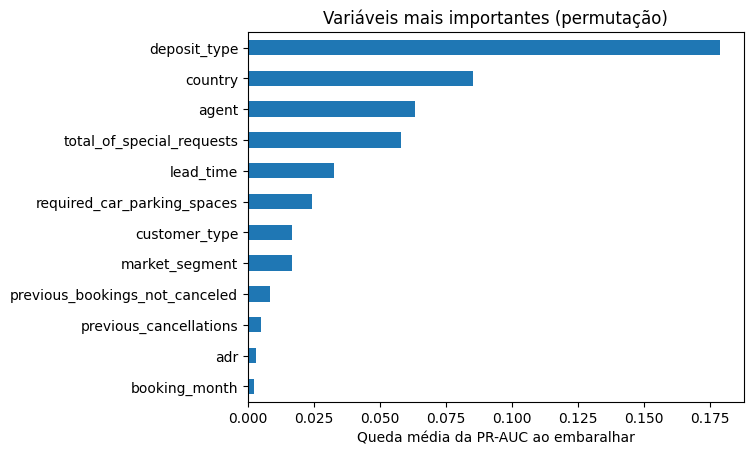

In [5]:
importancia.head(12).iloc[::-1].plot(kind="barh")
plt.xlabel("Queda média da PR-AUC ao embaralhar")
plt.title("Variáveis mais importantes (permutação)")
plt.show()

In [6]:
# guarda a figura para o README (sobe uma pasta, entra em reports/figures)
plt.figure()
importancia.head(12).iloc[::-1].plot(kind="barh")
plt.xlabel("Queda média da PR-AUC ao embaralhar")
plt.title("Variáveis mais importantes (permutação)")
plt.tight_layout()
plt.savefig("../reports/figures/importancia_variaveis.png")
plt.close()

O tipo de depósito domina, seguido do país do cliente, do número de
solicitações especiais, da agência e do `lead_time`. É a mesma leitura dos
coeficientes da regressão logística, o que dá confiança.

## 4. SHAP

O SHAP explica uma previsão individual: para *uma* reserva, mostra quanto
cada variável empurrou a probabilidade para cima ou para baixo, partindo de
um valor base. Uso ele porque as duas análises acima são globais (valem para
o conjunto), e para o hotel também interessa entender *uma* reserva
específica. Não substitui as anteriores, complementa.

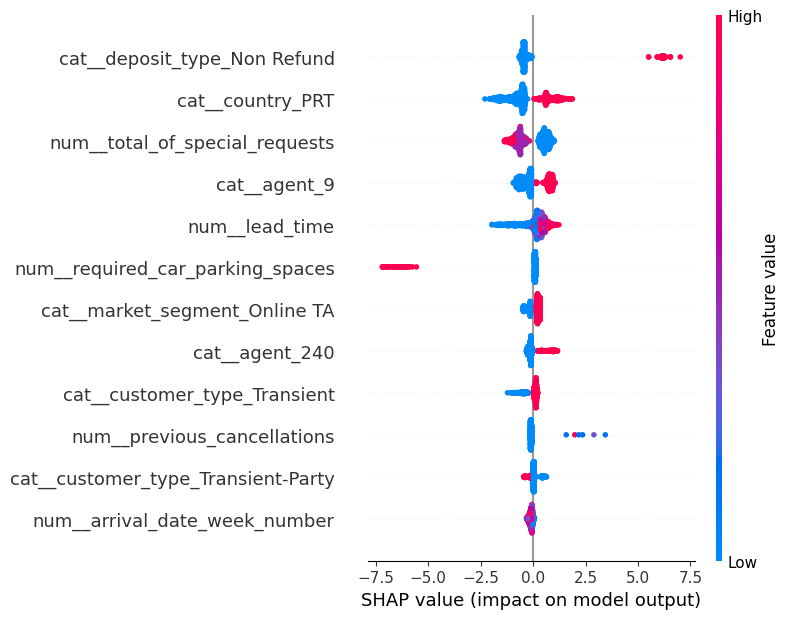

In [7]:
import shap

modelo_xgb = xgb.named_steps["modelo"]
prep = xgb.named_steps["prep"]

amostra = teste[variaveis].sample(1000, random_state=42)
amostra_p = prep.transform(amostra)

explicador = shap.TreeExplainer(modelo_xgb)
shap_valores = explicador.shap_values(amostra_p)
if isinstance(shap_valores, list):
    shap_valores = shap_valores[1]

shap.summary_plot(shap_valores, amostra_p, feature_names=list(nomes_saida),
                  max_display=12, show=False)
plt.tight_layout()
plt.show()

In [8]:
# uma reserva de alto risco, decomposta
i = amostra_p[np.argsort(-modelo_xgb.predict_proba(amostra_p)[:, 1])[0]]
contrib = pd.Series(explicador.shap_values(i.reshape(1, -1))[0] if not isinstance(
    explicador.shap_values(i.reshape(1, -1)), list) else explicador.shap_values(i.reshape(1, -1))[1][0],
    index=nomes_saida)
contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(10).round(2)

cat__deposit_type_Non Refund          6.080
cat__agent_58                         1.070
cat__country_PRT                      0.720
num__lead_time                        0.690
num__total_of_special_requests        0.470
cat__customer_type_Transient-Party    0.450
cat__market_segment_Groups            0.180
cat__booking_month_8                  0.150
cat__market_segment_Online TA        -0.130
cat__agent_9                         -0.130
dtype: float32

## 5. Análise de erros

In [9]:
teste = teste.copy()
teste["prob"] = xgb.predict_proba(teste[variaveis])[:, 1]
teste["pred"] = (teste["prob"] >= LIMIAR).astype(int)

fn = teste[(teste[ALVO] == 1) & (teste["pred"] == 0)]   # cancelou, não avisei
fp = teste[(teste[ALVO] == 0) & (teste["pred"] == 1)]   # avisei, não cancelou
tp = teste[(teste[ALVO] == 1) & (teste["pred"] == 1)]

print("falsos negativos:", len(fn), " falsos positivos:", len(fp))
print("recall no teste:", round(len(tp) / (len(tp) + len(fn)), 3))

falsos negativos: 2159  falsos positivos: 2733
recall no teste: 0.778


In [10]:
cols = ["lead_time", "adr", "total_nights", "total_of_special_requests",
        "previous_cancellations", "has_company"]
pd.DataFrame({
    "cancelou e avisei (TP)": tp[cols].mean(),
    "cancelou e NÃO avisei (FN)": fn[cols].mean(),
    "NÃO cancelou e avisei (FP)": fp[cols].mean(),
}).round(2)

,cancelou e avisei (TP),cancelou e NÃO avisei (FN),NÃO cancelou e avisei (FP)
lead_time,166.950,121.250,128.560
adr,135.170,147.690,143.160
total_nights,3.780,3.890,3.560
total_of_special_requests,0.250,1.250,0.580
previous_cancellations,0.000,0.010,0.010
has_company,0.020,0.020,0.030


Os falsos negativos são reservas de cancelamento que "parecem tranquilas":
`lead_time` mais curto e mais solicitações especiais. Os falsos positivos são
o contrário: `lead_time` longo e poucas solicitações, com cara de risco, mas
que foram mantidas. Ou seja, o modelo erra quando a reserva foge do padrão do
seu perfil.

## 6. O que levo para o próximo notebook

- os fatores de maior peso são o tipo de depósito, o país do cliente, as
  solicitações especiais, a agência e o `lead_time`;
- as três análises (coeficientes, permutação e SHAP) contam a mesma história,
  o que dá confiança de que não sobrou vazamento;
- os erros do modelo são coerentes com os perfis das reservas.

No notebook 09 treino a versão final e avalio uma única vez no teste.